# Decision Tree Classification on Iris Dataset

## Lab 5: Learning Decision Tree Classifiers for Non-Linear Decision Boundaries

**Objective:** Develop a decision tree model to classify species in the Iris dataset and evaluate its performance using accuracy, precision, recall, and F1-score metrics.

## 1. Import Required Libraries

Import all necessary libraries for data manipulation, model training, evaluation, and visualization.

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Training and Testing Data

Load the pre-processed training and testing datasets from CSV files.

In [2]:
# Load training and testing datasets
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

print("Training Data Shape:", train_data.shape)
print("Testing Data Shape:", test_data.shape)
print("\nFirst 5 rows of training data:")
print(train_data.head())

Training Data Shape: (596, 5)
Testing Data Shape: (150, 5)

First 5 rows of training data:
   sepal_length  sepal_width  petal_length  petal_width            label
0           5.5          2.4           3.8          1.0  Iris-versicolor
1           4.6          3.2           1.5          0.2      Iris-setosa
2           6.6          3.2           5.3          2.0   Iris-virginica
3           7.7          2.7           6.7          2.1   Iris-virginica
4           5.1          3.5           1.3          0.2      Iris-setosa


## 3. Separate Features and Labels

Split the datasets into feature matrices (X) and target vectors (y).

In [3]:
# Separate features (X) and labels (y) for training set
X_train = train_data[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y_train = train_data['label']

# Separate features (X) and labels (y) for testing set
X_test = test_data[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y_test = test_data['label']

print("Training Features Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)
print("\nTesting Features Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)
print("\nClass Distribution in Training Set:")
print(y_train.value_counts().sort_index())

Training Features Shape: (596, 4)
Training Labels Shape: (596,)

Testing Features Shape: (150, 4)
Testing Labels Shape: (150,)

Class Distribution in Training Set:
label
Iris-setosa        145
Iris-versicolor    204
Iris-virginica     247
Name: count, dtype: int64


## 4. Train Decision Tree Classifier

Create and train a Decision Tree Classifier with a fixed random state for reproducibility.

In [4]:
# Create Decision Tree Classifier with fixed random state for reproducibility
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model on training data
dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")
print("\nTree Depth:", dt_classifier.get_depth())
print("Number of Leaves:", dt_classifier.get_n_leaves())

Decision Tree Classifier trained successfully!

Tree Depth: 7
Number of Leaves: 12


## 5. Make Predictions on Test Set

Use the trained model to predict species labels for the test dataset.

In [5]:
# Make predictions on the test set
y_pred = dt_classifier.predict(X_test)

print("Predictions made successfully!")
print("\nFirst 10 predictions:")
print(y_pred[:10])
print("\nFirst 10 actual labels:")
print(y_test.values[:10])

Predictions made successfully!

First 10 predictions:
['Iris-virginica' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-virginica']

First 10 actual labels:
['Iris-virginica' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-virginica']


## 6. Evaluate Model Performance

### 6.1 Accuracy Score

Calculate the overall accuracy of the model on the test set.

In [6]:
# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)

print("=" * 60)
print("MODEL ACCURACY")
print("=" * 60)
print(f"\nAccuracy Score: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print("=" * 60)

MODEL ACCURACY

Accuracy Score: 0.9800 (98.00%)


### 6.2 Classification Report

Display detailed metrics (precision, recall, F1-score) for each species class.

In [7]:
# Generate classification report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print("\nDetailed Performance Metrics for Each Species:\n")
print(classification_report(y_test, y_pred, target_names=['Setosa', 'Versicolor', 'Virginica']))
print("=" * 60)
print("\nMetrics Explanation:")
print("- Precision: Of all predicted positives, how many are actually positive")
print("- Recall: Of all actual positives, how many are correctly predicted")
print("- F1-Score: Harmonic mean of precision and recall")
print("- Support: Number of actual occurrences of the class in the test set")

CLASSIFICATION REPORT

Detailed Performance Metrics for Each Species:

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        37
  Versicolor       0.96      0.98      0.97        51
   Virginica       0.98      0.97      0.98        62

    accuracy                           0.98       150
   macro avg       0.98      0.98      0.98       150
weighted avg       0.98      0.98      0.98       150


Metrics Explanation:
- Precision: Of all predicted positives, how many are actually positive
- Recall: Of all actual positives, how many are correctly predicted
- F1-Score: Harmonic mean of precision and recall
- Support: Number of actual occurrences of the class in the test set


## 7. Visualize Decision Tree

Visualize the trained decision tree to understand how it makes decisions at different nodes. The tree shows:
- **Decision criteria** at each node (e.g., "petal_length <= 2.45")
- **Gini impurity** - measure of node purity (0 = pure, 0.5 = mixed)
- **Samples** - number of training samples reaching that node
- **Value** - distribution of samples across classes
- **Class** - majority class at that node

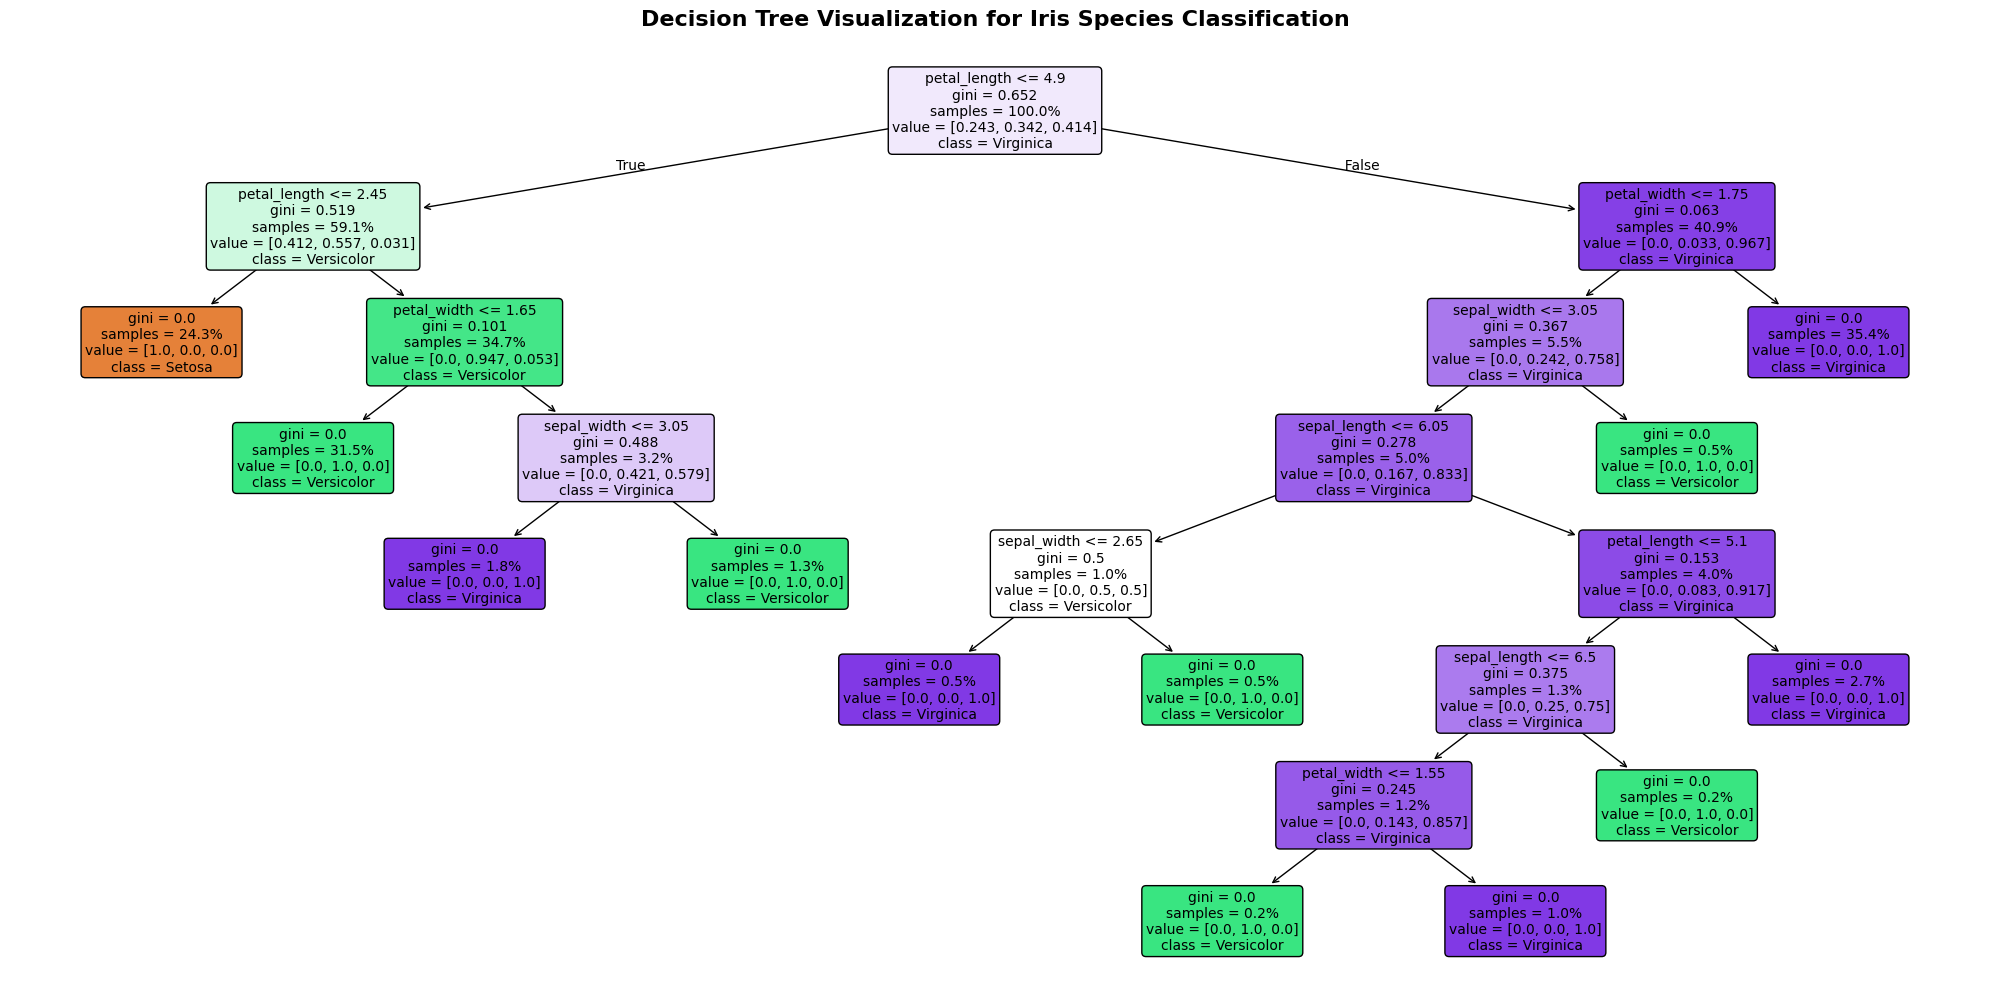


Decision Tree Visualization Complete!


In [11]:
# Create a figure for the decision tree visualization
plt.figure(figsize=(20, 10))

# Set a lighter color scheme for the tree boxes
from matplotlib.colors import ListedColormap

# Define pastel/light colors for the three iris species
light_colors = ['#FFE5E5', '#E5F5FF', '#F0FFE5']  # Light pink, light blue, light green
cmap = ListedColormap(light_colors)

# Plot the decision tree
plot_tree(dt_classifier, 
          feature_names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
          class_names=['Setosa', 'Versicolor', 'Virginica'],
          filled=True,
          rounded=True,
          fontsize=10,
          proportion=True)

plt.title("Decision Tree Visualization for Iris Species Classification", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Decision Tree Visualization Complete!")
print("=" * 60)

## 8. Summary and Conclusions

### Key Findings:

1. **Model Training**: Successfully trained a Decision Tree Classifier on the Iris dataset
2. **Performance Evaluation**: Evaluated using accuracy, precision, recall, and F1-score
3. **Tree Visualization**: Generated a visual representation showing decision boundaries and node splits

### Understanding the Decision Tree:

- **Non-Linear Boundaries**: Decision trees can capture complex, non-linear decision boundaries
- **Interpretability**: Each node represents a simple decision rule based on feature thresholds
- **Hierarchical Structure**: The tree makes decisions in a hierarchical manner, splitting data at each node
- **Feature Importance**: Features that appear higher in the tree are more important for classification

### Advantages of Decision Trees:

✓ Easy to understand and interpret  
✓ Requires little data preprocessing  
✓ Can handle both numerical and categorical data  
✓ Captures non-linear relationships  
✓ Visual representation available

---

**Experiment completed successfully!**